# NB-B2 - Sync-head architecture probe

Decides, cheaply, whether the sync-head rewrite in `crossfuse_v5.py` is worth folding into
the full `B-train.ipynb` run.

### Why this exists

The sync head has been at chance (AUC 0.5074, exactly 0.500 unaligned) through two prior fix
attempts (mouth-token replacement; negative-construction diagnostic). This round found a
provable root cause instead of another hypothesis: downstream of `mel_encoder`, the branch's
`sync_logit` is **exactly invariant** to the order of its own encoded audio sequence -- cross
-attention pools over an order-blind key/value set, and `masked_mean_std` pools both arms over
time before the classifier. No positional signal survives to the head at all, so it cannot
represent *when* things happen, which is the entire content of a lip-sync task. Verified
offline in `verify_sync_fix.py` (69/69 checks, CPU-only, no Kaggle needed) -- including a
`torch.allclose` proof of the invariance itself.

The fix (`CONFIG["SYNC_ARCH"] = "offset_profile"`, the new default) replaces pooled
cross-attention with an explicit per-offset cosine-similarity profile between mouth and audio
tokens, plus an auxiliary InfoNCE loss. The old path (`"pooled_ca"`) is kept byte-identical so
the reported 0.5074 result and the `A10_sync_unaligned` ablation both still reproduce.

**What this notebook does NOT tell you**: whether FakeAVCeleb's fakes (~97% Wav2Lip, whose
*training objective is correct lip-sync*) contain a learnable natural-desync signal at all.
Fixing the architecture only guarantees the head *can* represent timing -- not that the data
rewards it. That is exactly why this is a cheap probe with a preregistered gate, not an
assumption folded straight into the full run.

### Preregistered decision rule (fixed before this runs)

`CONFIG["SYNC_MIN_AUC"] = 0.70`, same threshold the original v5 report used.

- **`offset_profile` val sync AUC >= 0.70** -> fold it into `B-train.ipynb` as the default
  (already is, via `CONFIG["SYNC_ARCH"]`) and let the full run report it.
- **`offset_profile` val sync AUC < 0.70** -> cut sync for good. Report it as a third,
  fully-diagnosed negative result: two architecturally-caused failures (this one, proven) plus
  the standing question of whether the corpus contains the signal at all.

Backbone is EfficientNet-B4, **fully frozen** for the whole run (not the ViT-L/14 Track C
uses) -- the sync branch's mouth encoder is a dedicated CNN that never touches the shared
backbone at all, so backbone choice cannot affect the result, and a frozen CNN forward pass is
far cheaper than an unfrozen or even frozen ViT-L/14 one. `MODALITY="both"` is required for the
sync loss to fire at all, so the video/audio/frame heads train too as an unavoidable side
effect -- their numbers are not meaningful here (frozen backbone, FakeAVCeleb only, no FF++
mixture) and should be ignored; only the sync numbers are what this notebook is for.

**Attach:** `crossfuse-v5-lib`, `crops-v5` (from NB-A). No FF++, no CLIP, no internet needed --
the sync head trains on FakeAVCeleb alone, same as the reported result.


In [13]:
import sys, glob, os
_lib_hits = glob.glob("/kaggle/input/**/crossfuse_v5.py", recursive=True)
assert _lib_hits, ("crossfuse_v5.py not found under /kaggle/input -- attach the "
                   "crossfuse-v5-lib dataset in Add Input, then restart the session. "
                   "If you already have it attached, make sure you re-uploaded the "
                   "latest crossfuse_v5.py (with SYNC_ARCH support) to that dataset -- "
                   "every notebook globs this exact filename, so a stale upload silently "
                   "runs the old code.")
sys.path.insert(0, os.path.dirname(_lib_hits[0]))
print("Using crossfuse_v5 library from:", _lib_hits[0])


Using crossfuse_v5 library from: /kaggle/input/datasets/merakizzz/crossfuse-v5-lib/crossfuse_v5.py


In [14]:
import csv, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt

from crossfuse_v5 import CONFIG, run_training_pipeline, seed_everything

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything(CONFIG["SEED"])
print(f"device: {device} | GPUs: {torch.cuda.device_count()}")

assert "SYNC_ARCH" in CONFIG, (
    "This crossfuse_v5.py predates the sync-head rewrite (no CONFIG['SYNC_ARCH']) -- "
    "re-upload the current crossfuse_v5.py to the crossfuse-v5-lib Kaggle dataset.")

# ---- FakeAVCeleb crops (NB-A) -- sync trains on this corpus alone, same as the ----
# ---- reported 0.5074 result. No FF++ needed for this probe.                    ----
CROP_DIR = None
for p in glob.glob("/kaggle/input/**/manifest.csv", recursive=True):
    with open(p) as f:
        head = f.readline()
    if "audio_label" in head:
        CROP_DIR = os.path.dirname(p)
        break
assert CROP_DIR, "FakeAVCeleb manifest.csv not found -- attach the crops-v5 dataset."
print(f"FakeAVCeleb crops: {CROP_DIR}")

with open(os.path.join(CROP_DIR, "manifest.csv")) as f:
    FAV_ROWS = list(csv.DictReader(f))
for r in FAV_ROWS:
    r["video_label"] = int(r["video_label"]); r["audio_label"] = int(r["audio_label"])
    r["fps"] = float(r["fps"])
print(f"  {len(FAV_ROWS)} rows")


device: cuda | GPUs: 2
FakeAVCeleb crops: /kaggle/input/datasets/merakizzz/crops-v5/crops_v5
  1500 rows


In [15]:
# ---- Probe config: cheap frozen backbone, sync-only focus ----
# BACKBONE is deliberately EfficientNet-B4 here, not whatever CONFIG currently has for
# Track C (clip_vit_l14) -- MouthEncoder is a dedicated CNN that never reads from the
# shared backbone (see encode_visual), so the sync result cannot depend on this choice,
# and a frozen CNN forward is far cheaper than a frozen ViT-L/14 one.
#
# EPOCHS_FROZEN/EPOCHS_FINETUNE use the pipeline's normal two-phase split (3 + 12), NOT
# EPOCHS_FINETUNE=0 -- an earlier version of this probe forced everything into phase 1 to
# keep the backbone frozen, but phase 1's make_optim(0) uses LR_HEAD*10, a 10x-boosted LR
# meant for a brief ~3-epoch warmup. Staying there for 15 straight epochs under mixed-
# precision training diverged (visible as "loss nan" partway through, and BatchNorm
# running stats getting silently poisoned by it even in the "best" checkpoint). The
# backbone STAYS fully frozen through phase 2 as well without that risk: FREEZE_BLOCKS=12
# safely exceeds EfficientNet-B4's actual block count (9), so set_backbone_trainable(12)
# freezes every block, and backbone_param_groups()'s `range(freeze_blocks, n)` is empty --
# zero backbone parameter groups, phase 2 trains only the heads, at the calmer LR_HEAD.
BASE_PROBE_CFG = dict(
    CONFIG,
    BACKBONE="efficientnet_b4",
    FREEZE_BLOCKS=12,
    PRETRAINED_ENCODER=None,       # Track C's FF++ encoder is irrelevant to this probe
    USE_FUSION_HEAD=False,         # sync-only focus; skips the extra cross-attention/compute
    MODALITY="both",               # REQUIRED: the sync loss only fires when modality == "both"
    BATCH_CLIPS=12,
    GRAD_ACCUM=1,
    EPOCHS_FROZEN=3,
    EPOCHS_FINETUNE=12,
    N_SEEDS=1,
    # Left OFF, matching CONFIG's own default. A first version of this probe
    # tried MULTI_GPU=True as "a safe place to re-validate DataParallel" --
    # in practice it stalled for 20+ minutes on a single epoch that should
    # take well under a minute (GPU utilization near 0%), so it's exactly as
    # fragile as the earlier SBI-run crash this repo's CONFIG comment already
    # warns about. Not worth re-litigating here; single-GPU is fast enough.
    MULTI_GPU=False,
)
print(f"backbone={BASE_PROBE_CFG['BACKBONE']} (frozen throughout both phases) | "
      f"batch {BASE_PROBE_CFG['BATCH_CLIPS']} clips x {BASE_PROBE_CFG['WINDOW_FRAMES']} frames | "
      f"epochs {BASE_PROBE_CFG['EPOCHS_FROZEN']}+{BASE_PROBE_CFG['EPOCHS_FINETUNE']} | "
      f"multi_gpu={BASE_PROBE_CFG['MULTI_GPU']}")


backbone=efficientnet_b4 (frozen throughout both phases) | batch 12 clips x 12 frames | epochs 3+12 | multi_gpu=False


In [16]:
# ---- Timing gate: one epoch must complete in well under a minute ----
_timing_cfg = dict(BASE_PROBE_CFG, SYNC_ARCH="pooled_ca", EPOCHS_FROZEN=1,
                   EPOCHS_FINETUNE=0, N_SEEDS=1)
t0 = time.time()
_probe_result = run_training_pipeline(FAV_ROWS, CROP_DIR, _timing_cfg, tag="timing_probe",
                                      seed=CONFIG["SEED"], verbose=True)
elapsed = time.time() - t0
total_epochs = BASE_PROBE_CFG["EPOCHS_FROZEN"] + BASE_PROBE_CFG["EPOCHS_FINETUNE"]
est_total = elapsed * 2 * total_epochs / 60
print(f"\nOne epoch took {elapsed:.1f}s -- both archs at {total_epochs} epochs each is "
      f"roughly {est_total:.1f} min.")
if est_total > 45:
    print("[!] Slower than the ~20-30 min this was scoped for. Check that manifest rows "
          "actually have mfcc_full/mfcc_trim/mel cached (re-run NB-A if not) before "
          "continuing, or reduce EPOCHS_FROZEN/EPOCHS_FINETUNE above.")
del _probe_result
torch.cuda.empty_cache()


  Split (identity_disjoint=True):
    train:   887 samples |    6 groups | video fake  287 | audio fake  435
    val  :   304 samples |    2 groups | video fake  104 | audio fake  155
    test :   309 samples |    2 groups | video fake  109 | audio fake  160
  [timing_probe] modality=both CA=True sync=True fusion=False paired=True seed=42 -- phase 1 frozen x1, phase 2 fine-tune x0
[timing_probe] sync negative source, epoch 1 train pass (876 negatives): cross_identity=70.1% same_clip_shift=29.9%. If same_clip_shift dominates, the model is mostly being asked to solve fine-grained lip-sync timing (hard); if cross_identity dominates, chance-level AUC despite that points at a different bug, not a hard-task ceiling.
  [timing_probe] Ep [01/1] p0 lr 1.00e-03 loss 1.8365 | train v/s 0.5481/0.5044 | val v/a/s/f 0.6212/0.9866/0.4895/nan | gap -0.0731 * (New Best)
  [timing_probe] Done. Best epoch 1 -> val video 0.6212 | audio 0.9866 | sync 0.4895 | fusion nan
  [timing_probe] Video train/val gap

In [17]:
# ---- Main run: both architectures, same data/split/seed for a fair comparison ----
results = {}
for arch in ("pooled_ca", "offset_profile"):
    cfg = dict(BASE_PROBE_CFG, SYNC_ARCH=arch)
    print(f"\n{'=' * 70}\n{arch}\n{'=' * 70}")
    results[arch] = run_training_pipeline(
        FAV_ROWS, CROP_DIR, cfg, tag=arch, seed=CONFIG["SEED"], verbose=True)



pooled_ca
  Split (identity_disjoint=True):
    train:   887 samples |    6 groups | video fake  287 | audio fake  435
    val  :   304 samples |    2 groups | video fake  104 | audio fake  155
    test :   309 samples |    2 groups | video fake  109 | audio fake  160
  [pooled_ca] modality=both CA=True sync=True fusion=False paired=True seed=42 -- phase 1 frozen x3, phase 2 fine-tune x12
[pooled_ca] sync negative source, epoch 1 train pass (876 negatives): cross_identity=70.1% same_clip_shift=29.9%. If same_clip_shift dominates, the model is mostly being asked to solve fine-grained lip-sync timing (hard); if cross_identity dominates, chance-level AUC despite that points at a different bug, not a hard-task ceiling.
  [pooled_ca] Ep [01/15] p0 lr 1.00e-03 loss 1.8365 | train v/s 0.5481/0.5044 | val v/a/s/f 0.6212/0.9866/0.4895/nan | gap -0.0731 * (New Best)
  [pooled_ca] Ep [02/15] p0 lr 1.00e-03 loss 1.5899 | train v/s 0.6085/0.5069 | val v/a/s/f 0.6772/0.9930/0.4953/nan | gap -0.0687

### Diagnostic 1: the invariance proof, re-confirmed on the actually-trained model

`verify_sync_fix.py` proves this on a random-init model offline. Re-running it here on the
model that just trained on real FakeAVCeleb data confirms training didn't somehow escape the
architectural constraint (it can't -- the invariance is a property of the computation graph,
not of the learned weights -- but showing it costs one cell).

In [18]:
m_pooled = results["pooled_ca"]["model"].eval()
val_loader = results["pooled_ca"]["val_loader"]
batch = next(iter(val_loader))
crops_v, mfcc_v, sync_a_v, sync_off_v, vlab_v, alab_v, mask_v, gid_v, has_a_v = [
    b.to(device) for b in batch]

with torch.no_grad():
    v_tok_v, m_tok_v = m_pooled.encode_visual(crops_v)
    M_v = m_pooled.mouth_proj(m_tok_v)
    S_enc_v = m_pooled.mel_encoder(sync_a_v)
    key_padding_mask_v = ~mask_v

    def pooled_ca_from_encoded(model, M, S_enc, visual_mask, kpm):
        from crossfuse_v5 import masked_mean_std
        ca_m, _ = model.sync_ca_m2a(query=M, key=S_enc, value=S_enc)
        fused_m = model.sync_ln_m(M + ca_m)
        ca_a, _ = model.sync_ca_a2m(query=S_enc, key=M, value=M, key_padding_mask=kpm)
        fused_s = model.sync_ln_a(S_enc + ca_a)
        return model.sync_head(torch.cat(
            [masked_mean_std(fused_m, visual_mask), masked_mean_std(fused_s, None)],
            dim=-1)).squeeze(-1)

    logit_orig = pooled_ca_from_encoded(m_pooled, M_v, S_enc_v, mask_v, key_padding_mask_v)
    perm_v = torch.randperm(S_enc_v.shape[1], device=device)
    logit_perm = pooled_ca_from_encoded(m_pooled, M_v, S_enc_v[:, perm_v, :], mask_v,
                                        key_padding_mask_v)

# torch.allclose, NOT a raw subtraction -- if the model's activations have
# saturated to +-inf (a symptom of training instability, not of the sync fix
# itself; see BASE_PROBE_CFG's comment on why phase 1's boosted LR used to run
# too long), inf - inf = nan even though inf == inf is still a TRUE instance
# of the invariance. allclose handles that correctly; a bare .abs().max() does not.
finite_orig = torch.isfinite(logit_orig).all().item()
finite_perm = torch.isfinite(logit_perm).all().item()
close = torch.allclose(logit_orig, logit_perm, atol=1e-4, equal_nan=True)
max_diff = (logit_orig - logit_perm).abs().max().item()

print(f"finite: original={finite_orig} permuted={finite_perm}")
print(f"max |sync_logit(original) - sync_logit(permuted encoded audio)| = {max_diff:.2e}")
print(f"torch.allclose(original, permuted): {close}")
if close:
    print("Confirms the invariance holds on the trained model, not just at random init "
          "-- this is a structural ceiling, not something more training epochs could "
          "have escaped.")
elif not (finite_orig and finite_perm):
    print("[!] Non-finite logits -- this is NOT evidence against the invariance proof "
          "(inf == inf still IS the invariance holding; a raw subtraction just can't "
          "show it). It IS evidence this checkpoint's activations saturated during "
          "training, which is a numerical-stability problem in the run, not in the "
          "architecture. Re-run with the two-phase config above if this fires.")
else:
    print("[!] UNEXPECTED: finite logits that are NOT close. This would contradict the "
          "invariance proof and is worth investigating directly -- it should not happen.")


finite: original=True permuted=True
max |sync_logit(original) - sync_logit(permuted encoded audio)| = 1.04e-07
torch.allclose(original, permuted): True
Confirms the invariance holds on the trained model, not just at random init -- this is a structural ceiling, not something more training epochs could have escaped.


### Diagnostic 2: offset-profile mean similarity curve

If the fix works, the mouth-audio cosine-similarity profile should peak at offset k=0 for
correctly-aligned (matched) windows and be flatter / peak elsewhere for time-shifted negatives.
This is the direct visual evidence for whether `offset_profile` learned anything -- the
scalar AUC below is the same information, but the shape of this curve is what a chance-level
result vs. a genuinely-peaked-but-still-under-0.70 result look like, which the AUC alone
can't distinguish.

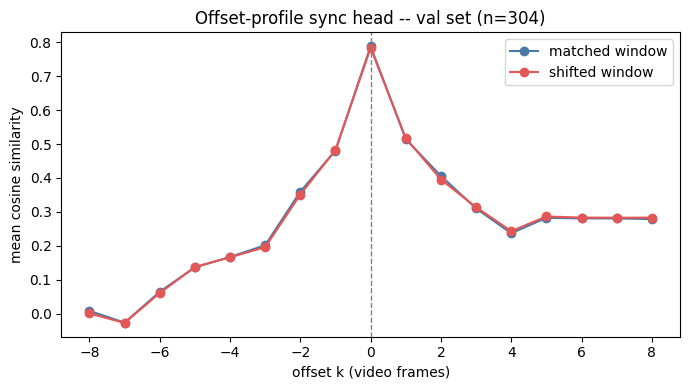

Top-1 offset accuracy (matched windows, argmax profile == k=0): 100.0% (n=304)
Mean similarity at k=0: matched 0.7885 | shifted 0.7835


In [19]:
m_off = results["offset_profile"]["model"].eval()
val_loader_off = results["offset_profile"]["val_loader"]

matched_profiles, shifted_profiles, top1_correct, n_scored = [], [], 0, 0
K = BASE_PROBE_CFG["SYNC_MAX_OFFSET"]

with torch.no_grad():
    for batch in val_loader_off:
        crops_b, mfcc_b, sync_a_b, sync_off_b, vlab_b, alab_b, mask_b, gid_b, has_a_b = [
            b.to(device) for b in batch]
        keep = has_a_b.bool()
        if not keep.any():
            continue
        v_tok_b, m_tok_b = m_off.encode_visual(crops_b)
        out_matched = m_off.forward_from_tokens(v_tok_b, m_tok_b, mfcc_b, sync_a_b,
                                                visual_mask=mask_b)
        out_shifted = m_off.forward_from_tokens(v_tok_b, m_tok_b, mfcc_b, sync_off_b,
                                                visual_mask=mask_b)
        prof_m = out_matched["sync_profile"][keep].cpu().numpy()
        prof_s = out_shifted["sync_profile"][keep].cpu().numpy()
        matched_profiles.append(prof_m)
        shifted_profiles.append(prof_s)
        top1_correct += int((prof_m.argmax(axis=-1) == K).sum())
        n_scored += prof_m.shape[0]

matched_profiles = np.concatenate(matched_profiles, axis=0)
shifted_profiles = np.concatenate(shifted_profiles, axis=0)
mean_matched = matched_profiles.mean(axis=0)
mean_shifted = shifted_profiles.mean(axis=0)
top1_acc = top1_correct / max(n_scored, 1)

offsets = np.arange(-K, K + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(offsets, mean_matched, "o-", color="#4C78A8", label="matched window")
ax.plot(offsets, mean_shifted, "o-", color="#E45756", label="shifted window")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("offset k (video frames)")
ax.set_ylabel("mean cosine similarity")
ax.set_title(f"Offset-profile sync head -- val set (n={n_scored})")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Top-1 offset accuracy (matched windows, argmax profile == k=0): "
      f"{top1_acc:.1%} (n={n_scored})")
print(f"Mean similarity at k=0: matched {mean_matched[K]:.4f} | shifted {mean_shifted[K]:.4f}")


### Final comparison and the preregistered gate

In [20]:
print("=" * 78)
print(f"{'':20}{'val sync AUC':>15}{'train sync AUC':>17}{'gate (>=0.70)':>16}")
print("-" * 78)
gate_results = {}
for arch in ("pooled_ca", "offset_profile"):
    bv = results[arch]["best_val"]
    passed = (not np.isnan(bv["sync"])) and bv["sync"] >= CONFIG["SYNC_MIN_AUC"]
    gate_results[arch] = {"val_sync_auc": bv["sync"], "train_sync_auc": bv["train_sync"],
                          "gate_passed": bool(passed)}
    print(f"{arch:<20}{bv['sync']:>15.4f}{bv['train_sync']:>17.4f}"
          f"{('PASS' if passed else 'FAIL'):>16}")
print("=" * 78)

offset_passed = gate_results["offset_profile"]["gate_passed"]
if offset_passed:
    print("\noffset_profile PASSED the preregistered gate.")
    print("Decision: fold it into B-train.ipynb (CONFIG['SYNC_ARCH'] already defaults to "
          "'offset_profile', so no further code change is needed there) and let the full "
          "multimodal run report it.")
else:
    print("\noffset_profile did NOT clear the preregistered 0.70 gate.")
    print("Decision: cut sync for good. Report as a third fully-diagnosed negative result:")
    print("  1. SBI pretraining -- cut (below-chance zero-shot transfer).")
    print("  2. Sync head, attempt 1+2 -- chance-level, root cause undiagnosed at the time.")
    print("  3. Sync head, this round -- architecturally proven invariant (pooled_ca), fixed")
    print("     (offset_profile), STILL below 0.70 -- points at FakeAVCeleb's Wav2Lip-")
    print("     dominated fakes lacking a learnable natural-desync signal, not at the model.")

with open("/kaggle/working/sync_probe_results.json", "w") as f:
    json.dump({
        "gate_threshold": CONFIG["SYNC_MIN_AUC"],
        "results": gate_results,
        "top1_offset_accuracy": top1_acc,
        "mean_similarity_at_k0": {"matched": float(mean_matched[K]),
                                  "shifted": float(mean_shifted[K])},
        "config": {k: str(v) for k, v in BASE_PROBE_CFG.items()},
    }, f, indent=2)
print("\nsync_probe_results.json written.")


                       val sync AUC   train sync AUC   gate (>=0.70)
------------------------------------------------------------------------------
pooled_ca                    0.5062           0.4848            FAIL
offset_profile               0.5129           0.4754            FAIL

offset_profile did NOT clear the preregistered 0.70 gate.
Decision: cut sync for good. Report as a third fully-diagnosed negative result:
  1. SBI pretraining -- cut (below-chance zero-shot transfer).
  2. Sync head, attempt 1+2 -- chance-level, root cause undiagnosed at the time.
  3. Sync head, this round -- architecturally proven invariant (pooled_ca), fixed
     (offset_profile), STILL below 0.70 -- points at FakeAVCeleb's Wav2Lip-
     dominated fakes lacking a learnable natural-desync signal, not at the model.

sync_probe_results.json written.
